In [43]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cassiopeia as cas
import json

In [2]:
# read in an allele table
allele_table = pd.read_csv("https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4905nnn/GSM4905334/suppl/GSM4905334_alleleTable.5k.txt.gz", sep='\t',
                           usecols = ['cellBC', 'intBC', 'r1', 'r2', 'r3', 'allele', 'LineageGroup', 'sampleID', 'readCount', 'UMI'])
indel_priors = cas.pp.compute_empirical_indel_priors(allele_table, grouping_variables=['intBC', 'LineageGroup'])


In [45]:
met_site_to_count = {x:0 for x in ['RW','RE','M2','M1','Liv']}
for clone in allele_table['LineageGroup'].unique():
    clone_allele_table = allele_table[allele_table['LineageGroup'] == clone]
    detected_sites = clone_allele_table['sampleID'].unique()
    for s in detected_sites:
        if s == 'LL': continue # primary sites
        met_site_to_count[s] += 1
print("met_site_to_count", met_site_to_count)
tot = sum(met_site_to_count.values())
met_site_to_freq = {k:(v/tot) for k,v in met_site_to_count.items()}

quinn_lt_dir = "/data/morrisq/divyak/projects/metient/metient/data/quinn_lt_2021"
with open(os.path.join(quinn_lt_dir, "quinn2021_m5k_organotropism.json"), 'w') as json_file:
    json.dump(met_site_to_freq, json_file, indent=4)  # Use indent for pretty printing


met_site_to_count {'RW': 85, 'RE': 84, 'M2': 89, 'M1': 91, 'Liv': 69}


<Figure size 800x200 with 0 Axes>

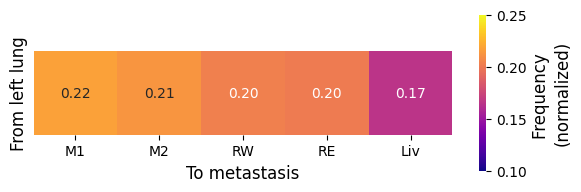

In [48]:
plt.figure(figsize=(8, 2))
sorted_transition_dict = dict(sorted(met_site_to_count.items(), key=lambda item: item[1], reverse=True))
states = list(sorted_transition_dict.keys())
frequencies = np.array(list(sorted_transition_dict.values()))
total = frequencies.sum()  # Sum of transitions for normalization

# Normalize the frequencies to range between 0 and 1
normalized_frequencies = frequencies / total

# Create a heatmap
plt.figure(figsize=(6, 2))
ax = sns.heatmap(normalized_frequencies.reshape(1, -1), annot=True, cmap='plasma', 
            fmt='.2f', cbar_kws={'label': 'Frequency \n(normalized)', 'shrink':1.}, vmin=0.1, vmax=0.25)

ax.set_aspect('equal', adjustable='box')
plt.xlabel("To metastasis", fontsize=12)
plt.ylabel("From left lung", fontsize=12)
# Adjust the font size of the color bar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10) 
cbar.set_label('Frequency \n(normalized)', fontsize=12) 

ax.set_xticklabels(states, ha='center')
plt.yticks([])  # Hide y-ticks since there's only one row

plt.tight_layout()
plt.savefig(os.path.join("/data/morrisq/divyak/projects/metient/metient/jupyter_notebooks/output_plots","quinn2021_m5k_organotropism.png"), dpi=300)
plt.show()